# Decision Tree Analysis for Telecom Customer Churn

## Assignment Objective

This notebook completes all six required analysis steps for the telecom churn dataset.

**Dataset:** `telecom_churn_data.csv`  
**Target variable:** `Churn`

For modeling:
- `False` / `0` = **No Churn**
- `True` / `1` = **Churn**

### Categorical encoding approach
The string predictor columns are converted to **integer class labels within their existing columns**. For example:

`State = [TX, OK, TX, AZ]` → integer category codes such as `[46, 36, 46, 3]`

The exact number assigned to a category is only an identifier. **No dummy columns and no additional engineered features are created.** The model therefore retains the original 19 predictor columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

# Step 1: Data Exploration

This step:
1. Loads the telecom churn dataset.
2. Displays the dataset shape and data types.
3. Checks for missing values.
4. Examines the percentage of customers who churned versus stayed.
5. Explains what the results mean.


In [2]:
# Load the telecom churn dataset
url = "https://raw.githubusercontent.com/jtian51/exercise-data/refs/heads/main/telecom_churn_data.csv"
df = pd.read_csv(url)

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values by column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



Dataset shape:
(3333, 20)

Data types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values by column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charg

In [3]:
# Analyze the target variable BEFORE converting it to 0/1
churn_counts_original = df["Churn"].value_counts().sort_index()
churn_percentages_original = df["Churn"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Count": churn_counts_original,
    "Percentage": churn_percentages_original
})

print("Churn Target Distribution:")
display(target_distribution)

print("Explanation:")
print(f"- The dataset contains {df.shape[0]:,} customer records and {df.shape[1]} total columns.")
print(f"- There are {df.shape[1] - 1} predictor columns and 1 target column (Churn).")
print(f"- Total missing values: {df.isnull().sum().sum()}.")

false_pct = churn_percentages_original.get(False, 0)
true_pct = churn_percentages_original.get(True, 0)

print(f"- No Churn (False): {false_pct:.2f}% of customers.")
print(f"- Churn (True): {true_pct:.2f}% of customers.")

if true_pct < false_pct:
    print("- Churn is the minority class, so overall accuracy alone may overstate model quality.")
    print("- Precision and recall for the Churn class will be especially important during evaluation.")

Churn Target Distribution:


,Count,Percentage
Churn,,
False,2850,85.508551
True,483,14.491449


Explanation:
- The dataset contains 3,333 customer records and 20 total columns.
- There are 19 predictor columns and 1 target column (Churn).
- Total missing values: 0.
- No Churn (False): 85.51% of customers.
- Churn (True): 14.49% of customers.
- Churn is the minority class, so overall accuracy alone may overstate model quality.
- Precision and recall for the Churn class will be especially important during evaluation.


### Step 1 Interpretation

The data exploration establishes the size, structure, and quality of the dataset before modeling. Checking data types identifies which variables require encoding, while the missing-value check determines whether imputation or row removal is necessary.

The churn distribution is particularly important because customer churn is typically the smaller class. When one class is much larger than the other, a model can achieve apparently high accuracy by favoring the majority class. For this reason, later sections evaluate **precision, recall, F1-score, and the confusion matrix** in addition to accuracy.


# Step 2: Feature Analysis

This step:
1. Separates predictors (`X`) from the target (`y`).
2. Converts only string predictor values to integer category labels while keeping each variable in one column.
3. Calculates the **top 10 features most correlated with churn**.
4. Explains the direction and business implications of those relationships.


In [4]:
# Separate features (X) and target (y)
X = df.drop(columns="Churn").copy()
y = df["Churn"].astype(int)

print(f"Predictor shape before encoding: {X.shape}")
print(f"Target shape: {y.shape}")

# Identify only string/object predictor columns
string_columns = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("\nString predictor columns:")
print(string_columns)

# Encode each string column in place.
# This does NOT create additional columns.
encoding_maps = {}

for column in string_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    encoding_maps[column] = {
        category: int(code)
        for category, code in zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    }

print(f"\nPredictor shape after encoding: {X.shape}")
print(f"Number of predictors before encoding: {df.shape[1] - 1}")
print(f"Number of predictors after encoding: {X.shape[1]}")
print(f"All predictor columns numeric: {all(pd.api.types.is_numeric_dtype(dtype) for dtype in X.dtypes)}")

print("\nCategory-to-integer mappings:")
for column, mapping in encoding_maps.items():
    print(f"\n{column}:")
    print(mapping)

print("\nFirst five encoded predictor rows:")
display(X.head())

Predictor shape before encoding: (3333, 19)
Target shape: (3333,)

String predictor columns:
['State', 'International plan', 'Voice mail plan']

Predictor shape after encoding: (3333, 19)
Number of predictors before encoding: 19
Number of predictors after encoding: 19
All predictor columns numeric: True

Category-to-integer mappings:

State:
{'AK': 0, 'AL': 1, 'AR': 2, 'AZ': 3, 'CA': 4, 'CO': 5, 'CT': 6, 'DC': 7, 'DE': 8, 'FL': 9, 'GA': 10, 'HI': 11, 'IA': 12, 'ID': 13, 'IL': 14, 'IN': 15, 'KS': 16, 'KY': 17, 'LA': 18, 'MA': 19, 'MD': 20, 'ME': 21, 'MI': 22, 'MN': 23, 'MO': 24, 'MS': 25, 'MT': 26, 'NC': 27, 'ND': 28, 'NE': 29, 'NH': 30, 'NJ': 31, 'NM': 32, 'NV': 33, 'NY': 34, 'OH': 35, 'OK': 36, 'OR': 37, 'PA': 38, 'RI': 39, 'SC': 40, 'SD': 41, 'TN': 42, 'TX': 43, 'UT': 44, 'VA': 45, 'VT': 46, 'WA': 47, 'WI': 48, 'WV': 49, 'WY': 50}

International plan:
{'No': 0, 'Yes': 1}

Voice mail plan:
{'No': 0, 'Yes': 1}

First five encoded predictor rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


### Encoding Interpretation

The encoding changes only the **values** stored in the original categorical columns. It does not add new predictor columns.

- `State` remains one column.
- `International plan` remains one column.
- `Voice mail plan` remains one column.
- All original numeric predictors remain unchanged.
- The predictor matrix therefore remains at **19 columns**.

**Important limitation:** `State` is a nominal category. Its integer codes are identifiers rather than a meaningful numeric order. Therefore, a Pearson correlation or a tree threshold involving the encoded `State` values should be interpreted cautiously. This encoding is being used here to keep the original column count as required.


Top 10 Features Most Correlated with Customer Churn:


,Feature,Correlation with Churn,Absolute Correlation
0,International plan,0.259852,0.259852
1,Customer service calls,0.208750,0.208750
2,Total day minutes,0.205151,0.205151
3,Total day charge,0.205151,0.205151
4,Voice mail plan,-0.102148,0.102148
5,Total eve minutes,0.092796,0.092796
6,Total eve charge,0.092786,0.092786
7,Number vmail messages,-0.089728,0.089728
8,Total intl charge,0.068259,0.068259
9,Total intl minutes,0.068239,0.068239


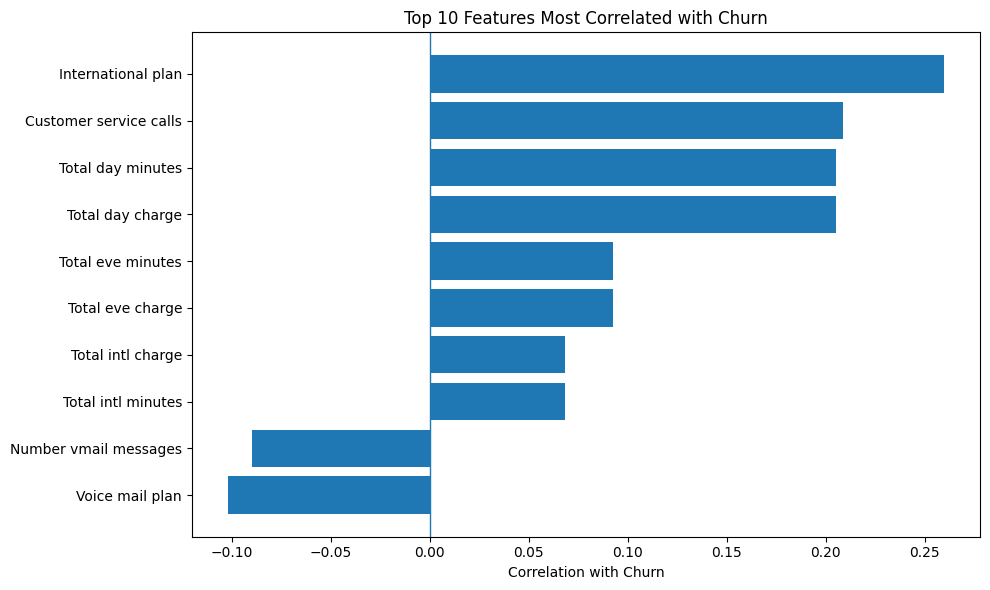

In [5]:
# Calculate signed correlations between every encoded predictor and Churn
correlation_series = pd.concat(
    [X, y.rename("Churn")],
    axis=1
).corr(numeric_only=True)["Churn"].drop("Churn")

# Rank by ABSOLUTE correlation strength, but retain the SIGN
top10_index = correlation_series.abs().sort_values(ascending=False).head(10).index
top10_correlations = correlation_series.loc[top10_index]

correlation_table = pd.DataFrame({
    "Feature": top10_correlations.index,
    "Correlation with Churn": top10_correlations.values,
    "Absolute Correlation": top10_correlations.abs().values
})

print("Top 10 Features Most Correlated with Customer Churn:")
display(correlation_table)

# Optional correlation visualization
plot_data = correlation_table.sort_values("Correlation with Churn")
plt.figure(figsize=(10, 6))
plt.barh(plot_data["Feature"], plot_data["Correlation with Churn"])
plt.axvline(0, linewidth=1)
plt.xlabel("Correlation with Churn")
plt.title("Top 10 Features Most Correlated with Churn")
plt.tight_layout()
plt.show()

In [6]:
# Explain the actual correlation results
print("CORRELATION INTERPRETATION")
print("-" * 70)

for _, row in correlation_table.iterrows():
    feature = row["Feature"]
    corr = row["Correlation with Churn"]

    if corr > 0:
        direction = "positive"
        meaning = "higher encoded/numeric values are associated with a higher likelihood of churn"
    elif corr < 0:
        direction = "negative"
        meaning = "higher encoded/numeric values are associated with a lower likelihood of churn"
    else:
        direction = "approximately zero"
        meaning = "there is little linear relationship with churn"

    print(f"{feature}: correlation = {corr:.4f} ({direction})")
    print(f"  Interpretation: {meaning}.")

    if feature == "State":
        print("  Caution: State codes are arbitrary category IDs, so this numeric correlation is not an ordinal state effect.")
    elif feature in ["International plan", "Voice mail plan"]:
        print(f"  Mapping used: {encoding_maps.get(feature, {})}")

    print()

print("Telecom retention implications:")
print("- Features with larger absolute correlations deserve closer investigation because they have stronger linear relationships with churn.")
print("- Positive relationships can help identify conditions associated with greater churn risk; negative relationships can indicate characteristics associated with customer retention.")
print("- Correlation does not prove causation, so these results should be combined with the decision-tree rules and business knowledge.")
print("- If usage, service-plan, charge, or customer-service variables rank highly, the telecom company can use them as early warning indicators for targeted retention outreach.")

CORRELATION INTERPRETATION
----------------------------------------------------------------------
International plan: correlation = 0.2599 (positive)
  Interpretation: higher encoded/numeric values are associated with a higher likelihood of churn.
  Mapping used: {'No': 0, 'Yes': 1}

Customer service calls: correlation = 0.2087 (positive)
  Interpretation: higher encoded/numeric values are associated with a higher likelihood of churn.

Total day minutes: correlation = 0.2052 (positive)
  Interpretation: higher encoded/numeric values are associated with a higher likelihood of churn.

Total day charge: correlation = 0.2052 (positive)
  Interpretation: higher encoded/numeric values are associated with a higher likelihood of churn.

Voice mail plan: correlation = -0.1021 (negative)
  Interpretation: higher encoded/numeric values are associated with a lower likelihood of churn.
  Mapping used: {'No': 0, 'Yes': 1}

Total eve minutes: correlation = 0.0928 (positive)
  Interpretation: higher e

# Step 3: Data Splitting

The data is divided into:
- **80% training data** for learning the decision rules.
- **20% test data** for evaluating the trained model on unseen customers.

`stratify=y` is used so that the churn percentage remains approximately the same in both sets.


In [7]:
# Create an 80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset Shapes")
print("-" * 50)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

def class_distribution(series, name):
    counts = series.value_counts().sort_index()
    pct = series.value_counts(normalize=True).sort_index() * 100

    table = pd.DataFrame({
        "Class": ["No Churn (0)", "Churn (1)"],
        "Count": [counts.get(0, 0), counts.get(1, 0)],
        "Percentage": [pct.get(0, 0), pct.get(1, 0)]
    })

    print(f"\n{name} class distribution:")
    display(table)
    return pct.get(1, 0)

overall_churn_rate = y.mean() * 100
train_churn_rate = class_distribution(y_train, "Training set")
test_churn_rate = class_distribution(y_test, "Test set")

print("Why stratification matters:")
print(f"- Overall churn rate: {overall_churn_rate:.2f}%")
print(f"- Training churn rate: {train_churn_rate:.2f}%")
print(f"- Test churn rate: {test_churn_rate:.2f}%")
print("- These rates are kept very similar by stratification.")
print("- This gives the model representative churn examples during training and makes the test evaluation more comparable to the full dataset.")
print("- Without stratification, one split could accidentally contain too many or too few churners, which could distort training or evaluation results.")

Dataset Shapes
--------------------------------------------------
X_train: (2666, 19)
X_test:  (667, 19)
y_train: (2666,)
y_test:  (667,)

Training set class distribution:


,Class,Count,Percentage
0,No Churn (0),2280,85.52138
1,Churn (1),386,14.47862



Test set class distribution:


,Class,Count,Percentage
0,No Churn (0),570,85.457271
1,Churn (1),97,14.542729


Why stratification matters:
- Overall churn rate: 14.49%
- Training churn rate: 14.48%
- Test churn rate: 14.54%
- These rates are kept very similar by stratification.
- This gives the model representative churn examples during training and makes the test evaluation more comparable to the full dataset.
- Without stratification, one split could accidentally contain too many or too few churners, which could distort training or evaluation results.


# Step 4: Model Building

A decision tree is trained using parameters chosen to balance churn detection and interpretability.

- `criterion='gini'`: evaluates the quality of potential splits.
- `max_depth=3`: keeps the tree shallow enough to explain.
- `class_weight='balanced'`: gives additional relative importance to the minority churn class.
- `min_samples_split=10`: prevents very small groups from being split unnecessarily.
- `min_samples_leaf=5`: ensures terminal groups contain a minimum number of observations.


In [8]:
# Build and train the decision tree
clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    class_weight="balanced",
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=5
)

clf.fit(X_train, y_train)

tree_depth = clf.get_depth()
tree_leaves = clf.get_n_leaves()

print("Decision Tree Training Complete")
print("-" * 50)
print(f"Tree depth: {tree_depth}")
print(f"Number of leaves: {tree_leaves}")

print("\nTree structure interpretation:")
print(f"- A depth of {tree_depth} means a customer passes through at most {tree_depth} split decisions before reaching a final prediction.")
print(f"- The {tree_leaves} leaves represent final customer segments created by the learned decision rules.")
print("- A shallow tree is easier for managers to interpret and reduces the risk of memorizing very specific training examples.")
print("- Each split identifies a customer characteristic and threshold that helps separate higher-risk and lower-risk churn groups.")

Decision Tree Training Complete
--------------------------------------------------
Tree depth: 3
Number of leaves: 8

Tree structure interpretation:
- A depth of 3 means a customer passes through at most 3 split decisions before reaching a final prediction.
- The 8 leaves represent final customer segments created by the learned decision rules.
- A shallow tree is easier for managers to interpret and reduces the risk of memorizing very specific training examples.
- Each split identifies a customer characteristic and threshold that helps separate higher-risk and lower-risk churn groups.


# Step 5: Tree Visualization and Analysis

This step:
1. Displays the decision tree.
2. Prints the decision rules in text form.
3. Extracts representative root-to-leaf decision pathways.
4. Ranks feature importance.
5. Explains the business significance of the strongest churn indicators.


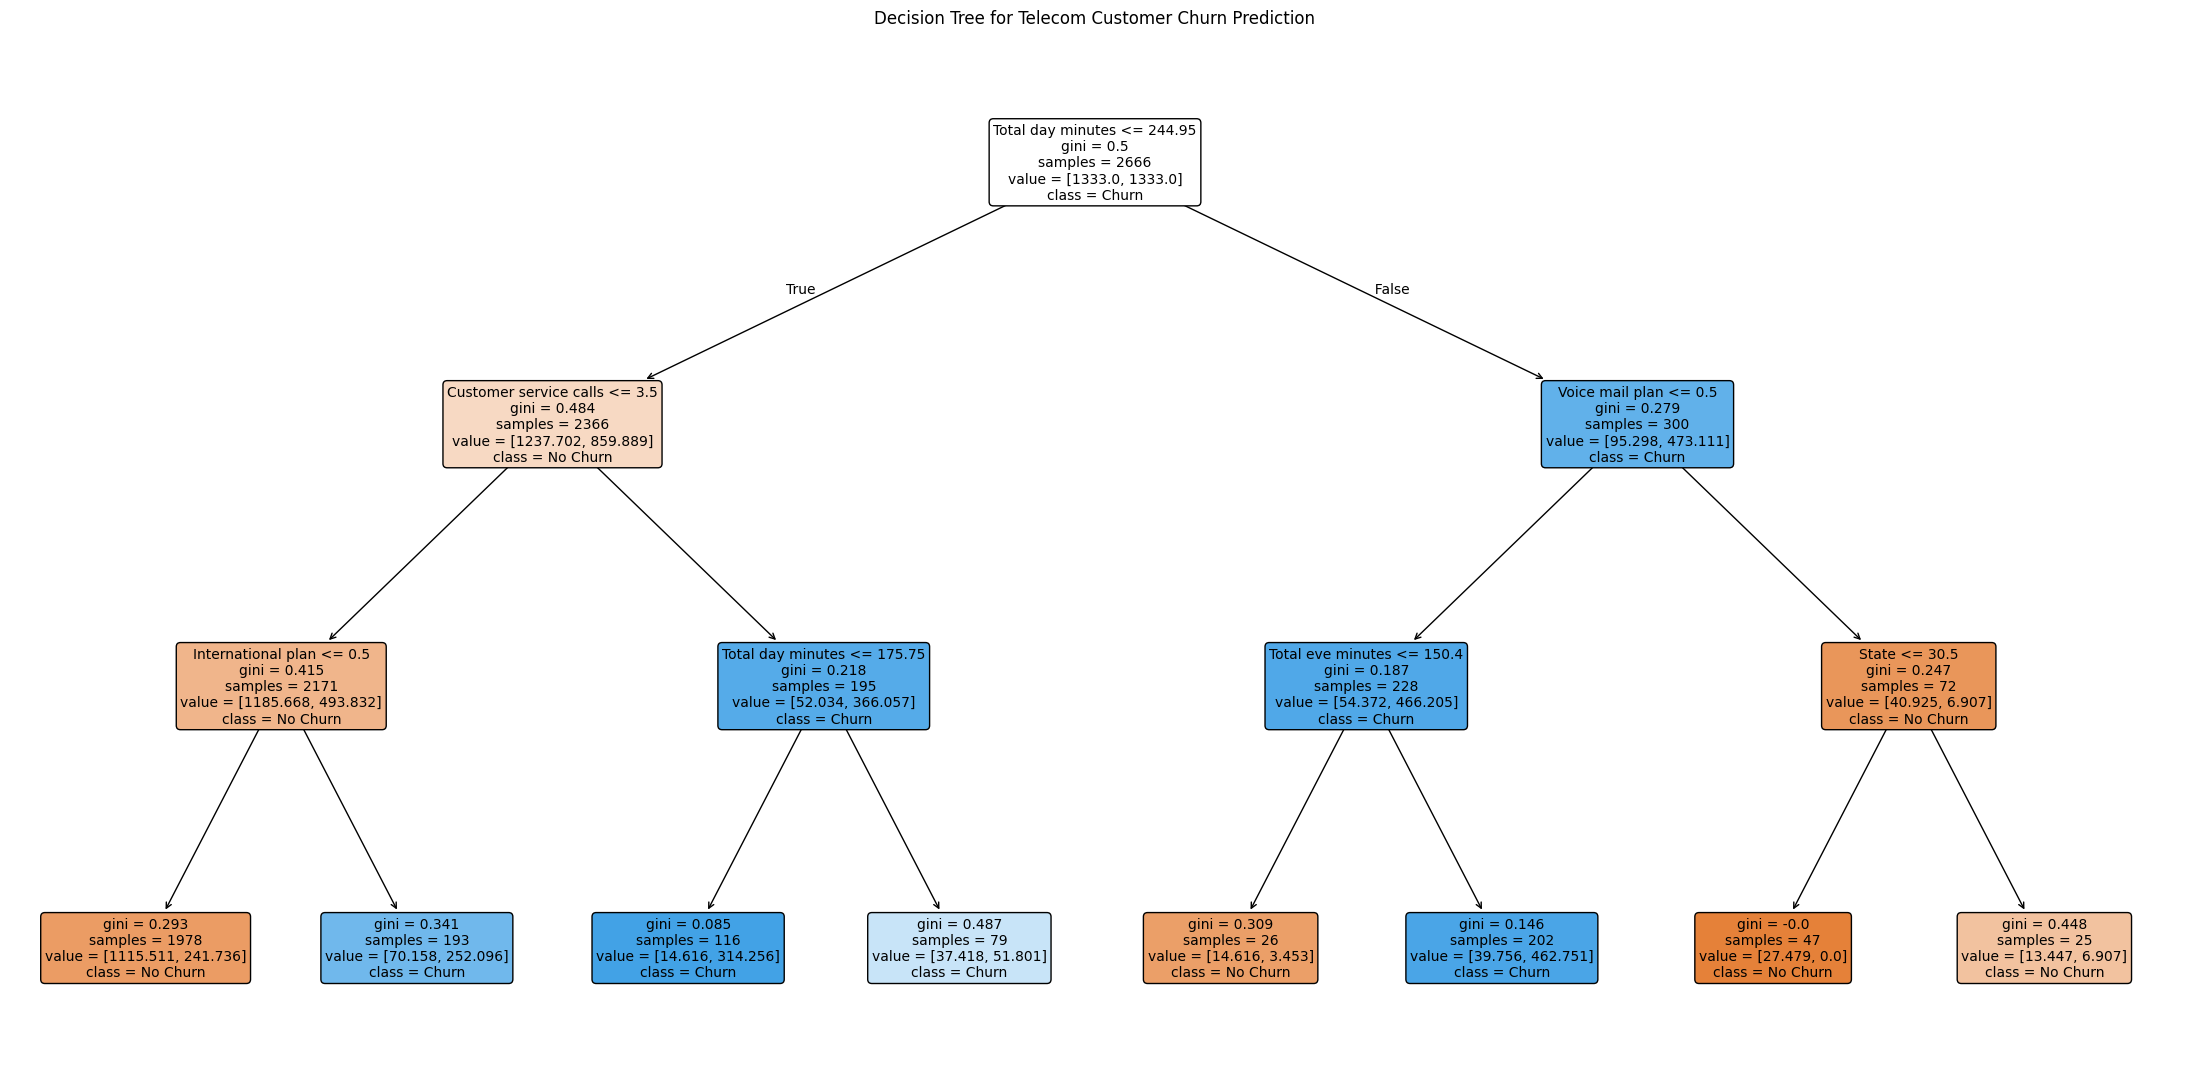

DECISION TREE RULES
----------------------------------------------------------------------
|--- Total day minutes <= 244.95
|   |--- Customer service calls <= 3.50
|   |   |--- International plan <= 0.50
|   |   |   |--- class: 0
|   |   |--- International plan >  0.50
|   |   |   |--- class: 1
|   |--- Customer service calls >  3.50
|   |   |--- Total day minutes <= 175.75
|   |   |   |--- class: 1
|   |   |--- Total day minutes >  175.75
|   |   |   |--- class: 1
|--- Total day minutes >  244.95
|   |--- Voice mail plan <= 0.50
|   |   |--- Total eve minutes <= 150.40
|   |   |   |--- class: 0
|   |   |--- Total eve minutes >  150.40
|   |   |   |--- class: 1
|   |--- Voice mail plan >  0.50
|   |   |--- State <= 30.50
|   |   |   |--- class: 0
|   |   |--- State >  30.50
|   |   |   |--- class: 0



In [9]:
# Display the decision tree
plt.figure(figsize=(22, 11))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Telecom Customer Churn Prediction")
plt.tight_layout()
plt.show()

# Display decision rules as text
tree_rules = export_text(clf, feature_names=list(X.columns))
print("DECISION TREE RULES")
print("-" * 70)
print(tree_rules)

In [10]:
# Extract and interpret representative decision pathways
tree_ = clf.tree_
feature_names = list(X.columns)
class_names = ["No Churn", "Churn"]

leaf_paths = []

def collect_leaf_paths(node=0, conditions=None):
    if conditions is None:
        conditions = []

    left = tree_.children_left[node]
    right = tree_.children_right[node]

    # Leaf node
    if left == right:
        predicted_class_index = int(np.argmax(tree_.value[node][0]))
        leaf_paths.append({
            "conditions": conditions.copy(),
            "predicted_class": class_names[predicted_class_index],
            "samples": int(tree_.n_node_samples[node])
        })
        return

    feature = feature_names[tree_.feature[node]]
    threshold = tree_.threshold[node]

    collect_leaf_paths(
        left,
        conditions + [f"{feature} <= {threshold:.2f}"]
    )
    collect_leaf_paths(
        right,
        conditions + [f"{feature} > {threshold:.2f}"]
    )

collect_leaf_paths()

# Show the most populated pathways first
leaf_paths = sorted(leaf_paths, key=lambda x: x["samples"], reverse=True)

print("REPRESENTATIVE DECISION PATHWAYS")
print("-" * 70)

for i, path in enumerate(leaf_paths[:5], start=1):
    print(f"Path {i}:")
    print("  IF " + " AND ".join(path["conditions"]))
    print(f"  THEN predict: {path['predicted_class']}")
    print(f"  Training customers reaching this leaf: {path['samples']}")
    print()

# Explain the root split
root_feature = feature_names[tree_.feature[0]]
root_threshold = tree_.threshold[0]

print("Root-node interpretation:")
print(f"- The first split uses '{root_feature}' at approximately {root_threshold:.2f}.")
print("- Because the root is the first decision applied to every customer, this variable is especially useful for separating customer groups in this fitted tree.")
print("- Following a complete root-to-leaf path shows how several customer characteristics work together to produce a churn or no-churn prediction.")

if root_feature == "State":
    print("- Caution: the State threshold is based on arbitrary category codes and should not be interpreted as a meaningful geographic ranking.")

REPRESENTATIVE DECISION PATHWAYS
----------------------------------------------------------------------
Path 1:
  IF Total day minutes <= 244.95 AND Customer service calls <= 3.50 AND International plan <= 0.50
  THEN predict: No Churn
  Training customers reaching this leaf: 1978

Path 2:
  IF Total day minutes > 244.95 AND Voice mail plan <= 0.50 AND Total eve minutes > 150.40
  THEN predict: Churn
  Training customers reaching this leaf: 202

Path 3:
  IF Total day minutes <= 244.95 AND Customer service calls <= 3.50 AND International plan > 0.50
  THEN predict: Churn
  Training customers reaching this leaf: 193

Path 4:
  IF Total day minutes <= 244.95 AND Customer service calls > 3.50 AND Total day minutes <= 175.75
  THEN predict: Churn
  Training customers reaching this leaf: 116

Path 5:
  IF Total day minutes <= 244.95 AND Customer service calls > 3.50 AND Total day minutes > 175.75
  THEN predict: Churn
  Training customers reaching this leaf: 79

Root-node interpretation:
- 

FEATURE IMPORTANCE RANKINGS
----------------------------------------------------------------------


,Feature,Importance
18,Customer service calls,0.339655
3,International plan,0.285238
6,Total day minutes,0.269029
4,Voice mail plan,0.074166
9,Total eve minutes,0.027872
0,State,0.004040
1,Account length,0.000000
2,Area code,0.000000
5,Number vmail messages,0.000000
8,Total day charge,0.000000


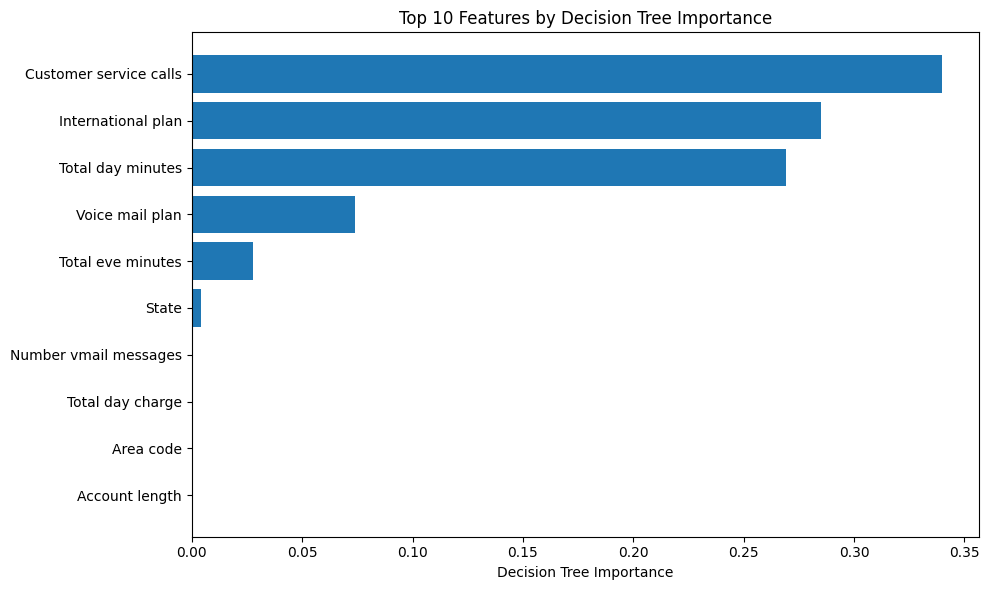

In [11]:
# Feature importance rankings
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values("Importance", ascending=False)

print("FEATURE IMPORTANCE RANKINGS")
print("-" * 70)
display(feature_importance.head(10))

# Visualize top feature importances
top_importance = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.xlabel("Decision Tree Importance")
plt.title("Top 10 Features by Decision Tree Importance")
plt.tight_layout()
plt.show()

In [12]:
# Explain feature importance and business significance
business_meanings = {
    "Customer service calls":
        "Frequent customer-service contacts can signal unresolved problems, dissatisfaction, or repeated service issues. These customers are strong candidates for proactive service recovery.",
    "International plan":
        "International-plan status can identify a customer segment with different pricing and usage needs. If it is highly important, the company should review the plan's pricing, value, and customer experience.",
    "Voice mail plan":
        "Voice-mail plan status may distinguish customer segments with different product usage and engagement patterns.",
    "Number vmail messages":
        "Voice-mail usage can reflect engagement with a service feature and may help separate different customer behavior profiles.",
    "Total day minutes":
        "Daytime usage reflects how intensively a customer uses the service. High importance suggests usage level and the associated cost experience help distinguish churn risk.",
    "Total day charge":
        "Daytime charges are closely connected to daytime usage. High importance can indicate that customers' daytime cost exposure is related to churn decisions.",
    "Total eve minutes":
        "Evening usage may help identify customer groups with different consumption patterns and churn risk.",
    "Total eve charge":
        "Evening charges reflect evening usage costs and may contribute to dissatisfaction or different customer value patterns.",
    "Total night minutes":
        "Night usage can distinguish customer behavior segments when the tree finds it useful.",
    "Total night charge":
        "Night charges capture cost associated with nighttime usage and may contribute to churn segmentation.",
    "Total intl minutes":
        "International usage can be important for customers whose service needs depend heavily on international calling.",
    "Total intl calls":
        "International call frequency can help identify customers with specialized calling needs.",
    "Total intl charge":
        "International charges can affect perceived plan value and can be relevant to retention for international callers.",
    "Account length":
        "Account tenure can distinguish newer and longer-standing customers with different retention behavior.",
    "Area code":
        "Area code can act as a geographic segment identifier, although it should not automatically be interpreted as a causal geographic effect.",
    "State":
        "State is encoded as an arbitrary category ID. Any importance means the tree used those codes to split records, but the numeric ordering itself has no geographic meaning."
}

print("TOP CHURN INDICATORS AND BUSINESS SIGNIFICANCE")
print("-" * 70)

for _, row in feature_importance.head(5).iterrows():
    feature = row["Feature"]
    importance = row["Importance"]
    explanation = business_meanings.get(
        feature,
        "This characteristic contributes to separating customers into churn and no-churn groups and should be investigated as a potential retention indicator."
    )
    print(f"{feature} — importance: {importance:.4f}")
    print(f"  Business significance: {explanation}")
    print()

print("Overall interpretation:")
print("- A higher feature-importance score means the decision tree relied more heavily on that variable when separating customer groups.")
print("- Importance does not mean causation; it indicates predictive usefulness within this fitted decision tree.")
print("- The most useful retention strategy is to combine the top indicators with the decision pathways. Customers matching high-risk pathways can be prioritized for proactive outreach, service recovery, plan review, or targeted retention offers.")

TOP CHURN INDICATORS AND BUSINESS SIGNIFICANCE
----------------------------------------------------------------------
Customer service calls — importance: 0.3397
  Business significance: Frequent customer-service contacts can signal unresolved problems, dissatisfaction, or repeated service issues. These customers are strong candidates for proactive service recovery.

International plan — importance: 0.2852
  Business significance: International-plan status can identify a customer segment with different pricing and usage needs. If it is highly important, the company should review the plan's pricing, value, and customer experience.

Total day minutes — importance: 0.2690
  Business significance: Daytime usage reflects how intensively a customer uses the service. High importance suggests usage level and the associated cost experience help distinguish churn risk.

Voice mail plan — importance: 0.0742
  Business significance: Voice-mail plan status may distinguish customer segments with dif

# Step 6: Performance Evaluation

The model is evaluated on the held-out test set using:

- **Accuracy:** percentage of all test customers classified correctly.
- **Precision for Churn:** among customers predicted to churn, the percentage who actually churned.
- **Recall for Churn:** among customers who actually churned, the percentage correctly identified by the model.
- **F1-score:** balance between churn precision and churn recall.
- **Confusion matrix:** counts of correct and incorrect predictions by class.
- **ROC-AUC:** additional measure of the model's ability to rank churn risk.

For a retention problem, churn **recall** is especially important because a false negative is an actual churner that the company failed to identify before the customer left.


In [13]:
# Make predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision_churn = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_churn = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_churn = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Churn Precision", "Churn Recall", "Churn F1-score", "ROC-AUC"],
    "Score": [accuracy, precision_churn, recall_churn, f1_churn, roc_auc]
})

print("MODEL PERFORMANCE")
print("-" * 70)
display(metrics_table)

print("Detailed Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    digits=4
))

print("Confusion Matrix:")
display(pd.DataFrame(
    cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
))

MODEL PERFORMANCE
----------------------------------------------------------------------


,Metric,Score
0,Accuracy,0.836582
1,Churn Precision,0.457143
2,Churn Recall,0.659794
3,Churn F1-score,0.540084
4,ROC-AUC,0.767019


Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn     0.9374    0.8667    0.9006       570
       Churn     0.4571    0.6598    0.5401        97

    accuracy                         0.8366       667
   macro avg     0.6973    0.7632    0.7204       667
weighted avg     0.8675    0.8366    0.8482       667

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,494,76
Actual Churn,33,64


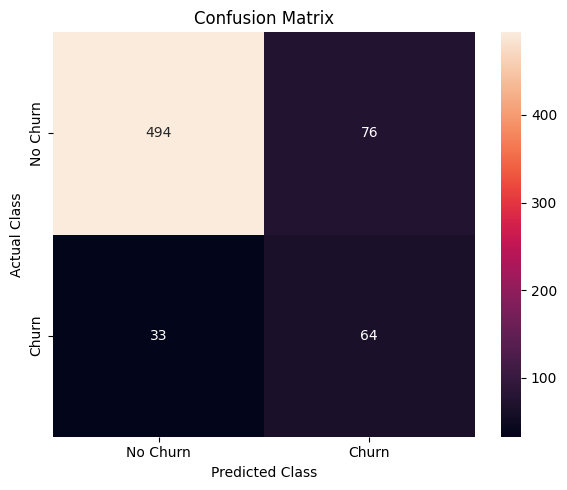

In [14]:
# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [15]:
# Interpret the model performance specifically for telecom churn
baseline_accuracy = (y_test == 0).mean()

print("PERFORMANCE INTERPRETATION FOR CUSTOMER CHURN")
print("-" * 70)

print(f"Accuracy = {accuracy:.2%}")
print(f"- The model correctly classifies {accuracy:.2%} of all customers in the test set.")

print(f"\nChurn precision = {precision_churn:.2%}")
print(f"- Of all customers the model flags as likely to churn, {precision_churn:.2%} actually churn.")
print(f"- There are {fp} false positives: customers flagged for churn who actually stayed.")

print(f"\nChurn recall = {recall_churn:.2%}")
print(f"- The model identifies {recall_churn:.2%} of all customers who actually churn.")
print(f"- It correctly identifies {tp} churners and misses {fn} churners.")

print(f"\nChurn F1-score = {f1_churn:.2%}")
print("- F1 summarizes the balance between precision and recall for the churn class.")

print(f"\nROC-AUC = {roc_auc:.4f}")
print("- ROC-AUC measures how well the model ranks churners above non-churners across possible classification thresholds.")

print("\nConfusion-matrix interpretation:")
print(f"- True Negatives (correctly predicted No Churn): {tn}")
print(f"- False Positives (predicted Churn, actually No Churn): {fp}")
print(f"- False Negatives (predicted No Churn, actually Churn): {fn}")
print(f"- True Positives (correctly predicted Churn): {tp}")

print(f"\nMajority-class baseline accuracy = {baseline_accuracy:.2%}")
if accuracy < baseline_accuracy:
    print("- The model's overall accuracy is below the accuracy obtained by always predicting No Churn.")
    print("- However, the majority-class baseline would identify zero churners, so churn recall and the confusion matrix are more informative for the retention objective.")
else:
    print("- The model exceeds the simple majority-class accuracy baseline.")

print("\nTELECOM RETENTION STRATEGY AND BUSINESS IMPACT")
print("- False negatives are especially costly because these are customers who actually leave without being flagged for intervention.")
print("- False positives create unnecessary retention contacts or offers, so low precision can increase campaign costs.")
print("- Recall shows how much of the true churn population the company can reach before customers leave.")
print("- Precision indicates how efficiently retention resources are being targeted.")
print("- The company can use predicted churn risk together with the tree's top indicators and decision pathways to prioritize proactive customer-service outreach.")
print("- Lower-cost interventions can be used for a broad at-risk group, while more expensive discounts or incentives can be reserved for customers with the highest predicted churn risk.")
print("- Model performance should be monitored over time because customer behavior, prices, products, and churn patterns can change.")

PERFORMANCE INTERPRETATION FOR CUSTOMER CHURN
----------------------------------------------------------------------
Accuracy = 83.66%
- The model correctly classifies 83.66% of all customers in the test set.

Churn precision = 45.71%
- Of all customers the model flags as likely to churn, 45.71% actually churn.
- There are 76 false positives: customers flagged for churn who actually stayed.

Churn recall = 65.98%
- The model identifies 65.98% of all customers who actually churn.
- It correctly identifies 64 churners and misses 33 churners.

Churn F1-score = 54.01%
- F1 summarizes the balance between precision and recall for the churn class.

ROC-AUC = 0.7670
- ROC-AUC measures how well the model ranks churners above non-churners across possible classification thresholds.

Confusion-matrix interpretation:
- True Negatives (correctly predicted No Churn): 494
- False Positives (predicted Churn, actually No Churn): 76
- False Negatives (predicted No Churn, actually Churn): 33
- True Positi

# Final Conclusion

This analysis completes all six required steps:

1. **Data Exploration:** inspected shape, data types, missing values, and churn percentages.
2. **Feature Analysis:** separated `X` and `y`, encoded only string values within their existing columns, calculated the top 10 correlations, and interpreted their retention implications.
3. **Data Splitting:** created an 80/20 stratified split and verified class balance.
4. **Model Building:** trained an interpretable decision tree and reported its depth and leaves.
5. **Tree Visualization and Analysis:** displayed the tree and text rules, interpreted representative decision pathways, ranked feature importance, and explained business significance.
6. **Performance Evaluation:** calculated accuracy, churn precision, churn recall, F1-score, ROC-AUC, and the confusion matrix, then translated the results into telecom retention and business implications.

### Key modeling note
The model keeps the original **19 predictor columns**. Categorical string variables are mapped to integer class labels without creating additional columns. Because `State` is a nominal category, its integer values should be treated as category identifiers rather than a meaningful numeric scale.


In [16]:
# Final modeling dataset check
modeling_df = X.copy()
modeling_df["Churn"] = y

print(f"Final modeling dataset shape: {modeling_df.shape}")
print(f"Predictor columns: {X.shape[1]}")
print(f"Target columns: 1")
display(modeling_df.head())

Final modeling dataset shape: (3333, 20)
Predictor columns: 19
Target columns: 1


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
